# Overview 



This notebook will demonstrate scRNA-seq preprocessing using data from hematopoiesis. (Paul, F., Arkin, Y., Giladi, A., Jaitin, D. A., Kenigsberg, E., Keren-Shaul, H., et al. (2015). Transcriptional Heterogeneity and Lineage Commitment in Myeloid Progenitors. Cell, 163(7), 1663–1677. http://doi.org/10.1016/j.cell.2015.11.013).

You can easily download this scRNA-seq data using Scanpy.

### Notebook file
Notebook file is available on CellOracle's GitHub page.
https://github.com/morris-lab/CellOracle/blob/master/docs/notebooks/03_scRNA-seq_data_preprocessing/scanpy_preprocessing_with_Paul_etal_2015_data.ipynb


### Steps

To preprocess the scRNA-seq data, we will do the following:

1. **Variable gene selection and normalization.**
2. **Log transformation.**  Like many preprocessing workflows, we need to log transform the data. However, CellOracle also needs the raw gene expression values, which we will store in an anndata layer.
3. **Cell clustering.** 
4. **Dimensional reduction.** We need to prepare the 2D embedding data. Please make sure that the 2D embedding properly represents the cell identities and processes of interest. Also, please consider the resolution and continuity of the data. CellOracle’s simulation results are only informative when the embedding is consistent with the questions being investigated.


### Caution

- This notebook is intended to help users **prepare the input data for CellOracle analysis**. This is **NOT** the CellOracle analysis itself. Also, this notebook does NOT use `celloracle` in this notebook.

- Instead, we use `Scanpy` and `Anndata` to process and store the scRNA-seq data. If you are new to these packages, please learn about them in advance.  

 - `Scanpy` documentation: https://scanpy.readthedocs.io/en/stable/
 - `Anndata` documentation: https://anndata.readthedocs.io/en/latest/


### Acknowledgement

- This scRNA-seq preprocessing notebook was made based on the Scanpy's tutorial.
https://scanpy-tutorials.readthedocs.io/en/latest/paga-paul15.html

# 0. Import libraries

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = [6, 4.5]

# 1. Load data


In [3]:
# Download dataset. You can change the code blow to use your data.
adata = sc.datasets.paul15()

# 2. Filtering

In [4]:
adata.X

array([[0., 0., 0., ..., 0., 2., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 3., ..., 2., 3., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [3., 0., 3., ..., 0., 1., 0.],
       [0., 0., 4., ..., 1., 1., 1.]], dtype=float32)

In [5]:
adata.__dict__

{'_is_view': False,
 '_adata_ref': None,
 '_oidx': None,
 '_vidx': None,
 'file': Backing file manager: no file is set.,
 '_X': array([[0., 0., 0., ..., 0., 2., 0.],
        [0., 0., 1., ..., 0., 1., 0.],
        [1., 0., 3., ..., 2., 3., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [3., 0., 3., ..., 0., 1., 0.],
        [0., 0., 4., ..., 1., 1., 1.]], dtype=float32),
 '_obs':        paul15_clusters
 W31105            7MEP
 W31106            15Mo
 W31107            3Ery
 W31108            15Mo
 W31109            3Ery
 ...                ...
 W39164            2Ery
 W39165          13Baso
 W39166            7MEP
 W39167            15Mo
 W39168            3Ery
 
 [2730 rows x 1 columns],
 '_var': Empty DataFrame
 Columns: []
 Index: [0610007L01Rik, 0610009O20Rik, 0610010K14Rik, 0910001L09Rik, 1100001G20Rik, 1110002B05Rik, 1110004E09Rik, 1110007A13Rik, 1110007C09Rik, 1110013L07Rik, 1110020G09Rik, 1110034G24Rik, 1110038B12Rik, 1110049F12Rik, 1110059E24Rik, 1190002H23Rik

In [6]:
# Only consider genes with more than 1 count
sc.pp.filter_genes(adata, min_counts=1)


# 3. Normalization

In [7]:
# Normalize gene expression matrix with total UMI count per cell
sc.pp.normalize_per_cell(adata, key_n_counts='n_counts_all')

/tmp/ipykernel_378077/2400592225.py:2: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, key_n_counts='n_counts_all')
/share/crsp/lab/pkaiser/ddlin/cell_fate/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


# 4. Identification of highly variable genes

**This step is essential. Please do not skip this step.**

> Removing non-variable genes reduces the calculation time during the GRN reconstruction and simulation steps.
It also improves the overall accuracy of the GRN inference by removing noisy genes.
We recommend using the top 2000~3000 variable genes. 

In [8]:
# Select top 2000 highly-variable genes
filter_result = sc.pp.filter_genes_dispersion(adata.X,
                                              flavor='cell_ranger',
                                              n_top_genes=2000,
                                              log=False)

# Subset the genes
adata = adata[:, filter_result.gene_subset]

# Renormalize after filtering
sc.pp.normalize_per_cell(adata)

/tmp/ipykernel_378077/2689374920.py:2: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = sc.pp.filter_genes_dispersion(adata.X,
/tmp/ipykernel_378077/2689374920.py:11: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata)
/share/crsp/lab/pkaiser/ddlin/cell_fate/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:588: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_n_counts] = counts_per_cell
/share/crsp/lab/pkaiser/ddlin/cell_fate/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


# 5. Log transformation
- •	We need to log transform and scale the data before we calculate the principal components, clusters, and differentially expressed genes.


- We also need to **keep the non-transformed gene expression data in a separate anndata layer** before the log transformation. We will use this data for celloracle analysis later. 


In [9]:
# keep raw cont data before log transformation
adata.raw = adata # This freezes your entire AnnData at that moment (counts, obs, var, etc.) into the special .raw slot.
adata.layers["raw_count"] = adata.raw.X.copy() # This takes just the count matrix (.raw.X) and makes a layer named "raw_count" inside adata.layers.


# Log transformation and scaling
sc.pp.log1p(adata) # replace adata.X with log(1 + counts)
sc.pp.scale(adata) 

# 6. PCA and neighbor calculations
These calculations are necessary to perform the dimensionality reduction and clustering steps.

In [ ]:
# PCA
sc.tl.pca(adata, svd_solver='arpack') # efficient when you only need the top ~10–50 PCs.

# Diffusion map
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20) # Get the local cell-cell relationships

sc.tl.diffmap(adata) # Compute a Diffusion Map Embedding
# What it does: Runs diffusion‐map spectral embedding on the neighbor graph you just built.
#  It finds new axes (“diffusion components”) that respect the manifold structure—capturing gradual transitions 
# (e.g. differentiation trajectories) more smoothly than PCA.

# Calculate neihbors again based on diffusionmap 
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_diffmap')

# PCA → KNN sets up a rough, low‐dimensional graph.
# Diffusion map smooths and re‐embeds that graph to highlight continuous structure.



/share/crsp/lab/pkaiser/ddlin/cell_fate/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-30 22:35:40.355069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753940140.374588  378077 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753940140.380592  378077 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753940140.394159  378077 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same targe

# 7. Cell clustering

In [12]:
sc.tl.louvain(adata, resolution=0.8)

/share/crsp/lab/pkaiser/ddlin/cell_fate/.venv/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# 8. Dimensionality reduction using PAGA and force-directed graphs

The dimensionality reduction step requires careful consideration when preparing data for a CellOracle analysis. For a successful analysis, the embedding should recapitulate the cellular transition of interest.

Please choose an algorithm that can accurately represent the developmental trajectory of your data. We recommend using one of the following dimensional reduction algorithms (or trajectory inference algorithms).
 - UMAP: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.umap.html#scanpy.tl.umap
 - TSNE: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.tsne.html#scanpy.tl.tsne
 - Diffusion map: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.diffmap.html#scanpy.tl.diffmap
 - Force-directed graph drawing: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.draw_graph.html#scanpy.tl.draw_graph
 

In this example, we use the workflow introduced in the scanpy trajectory inference tutorial. https://scanpy-tutorials.readthedocs.io/en/latest/paga-paul15.html This method uses a combination of three algorithms:diffusion map, force-directed graph, and PAGA.
- Step1: Calculate the PAGA graph.The PAGA data will determine the initial cluster positions for the force-directed graph calculation.
- Step2: Calculate the force-directed graph. 



In [ ]:
# PAGA graph construction
# A PAGA (“partition-based graph abstraction”) plot is simply a way to see how your clusters (or “partitions”) 
# of cells are connected to one another, distilled down from the full single-cell neighborhood graph.
#  Here’s how to read it:
sc.tl.paga(adata, groups='louvain')

In [14]:
plt.rcParams["figure.figsize"] = [6, 4.5]

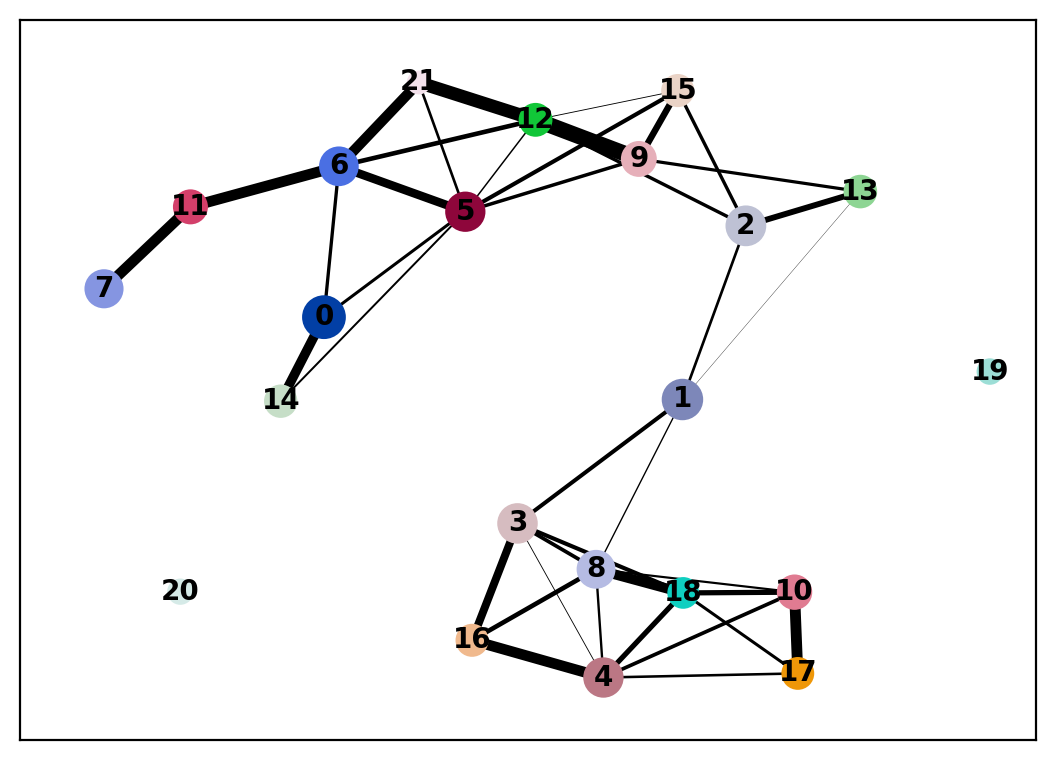

In [15]:
sc.pl.paga(adata)

In [17]:
sc.tl.draw_graph(adata, init_pos='paga', random_state=123)

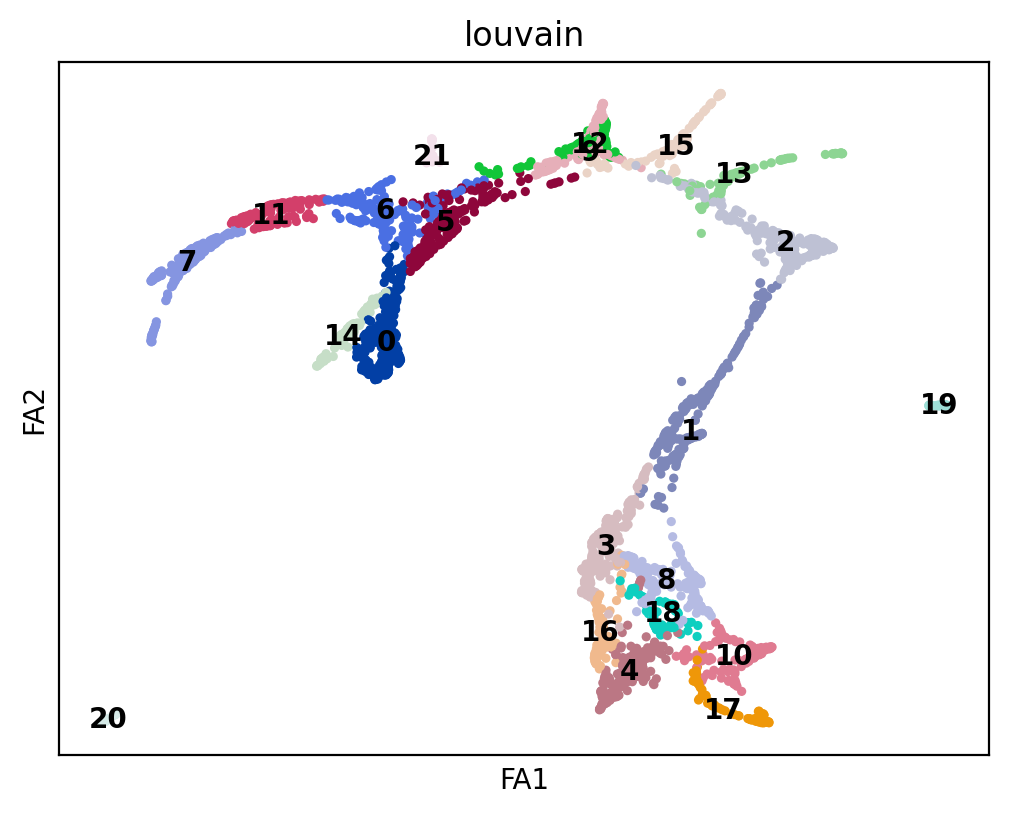

In [18]:
sc.pl.draw_graph(adata, color='louvain', legend_loc='on data')

# 9. Check data
## 9.1. Visualize marker gene expression

In [19]:
plt.rcParams["figure.figsize"] = [4.5, 4.5]

marker gene of Erythroids


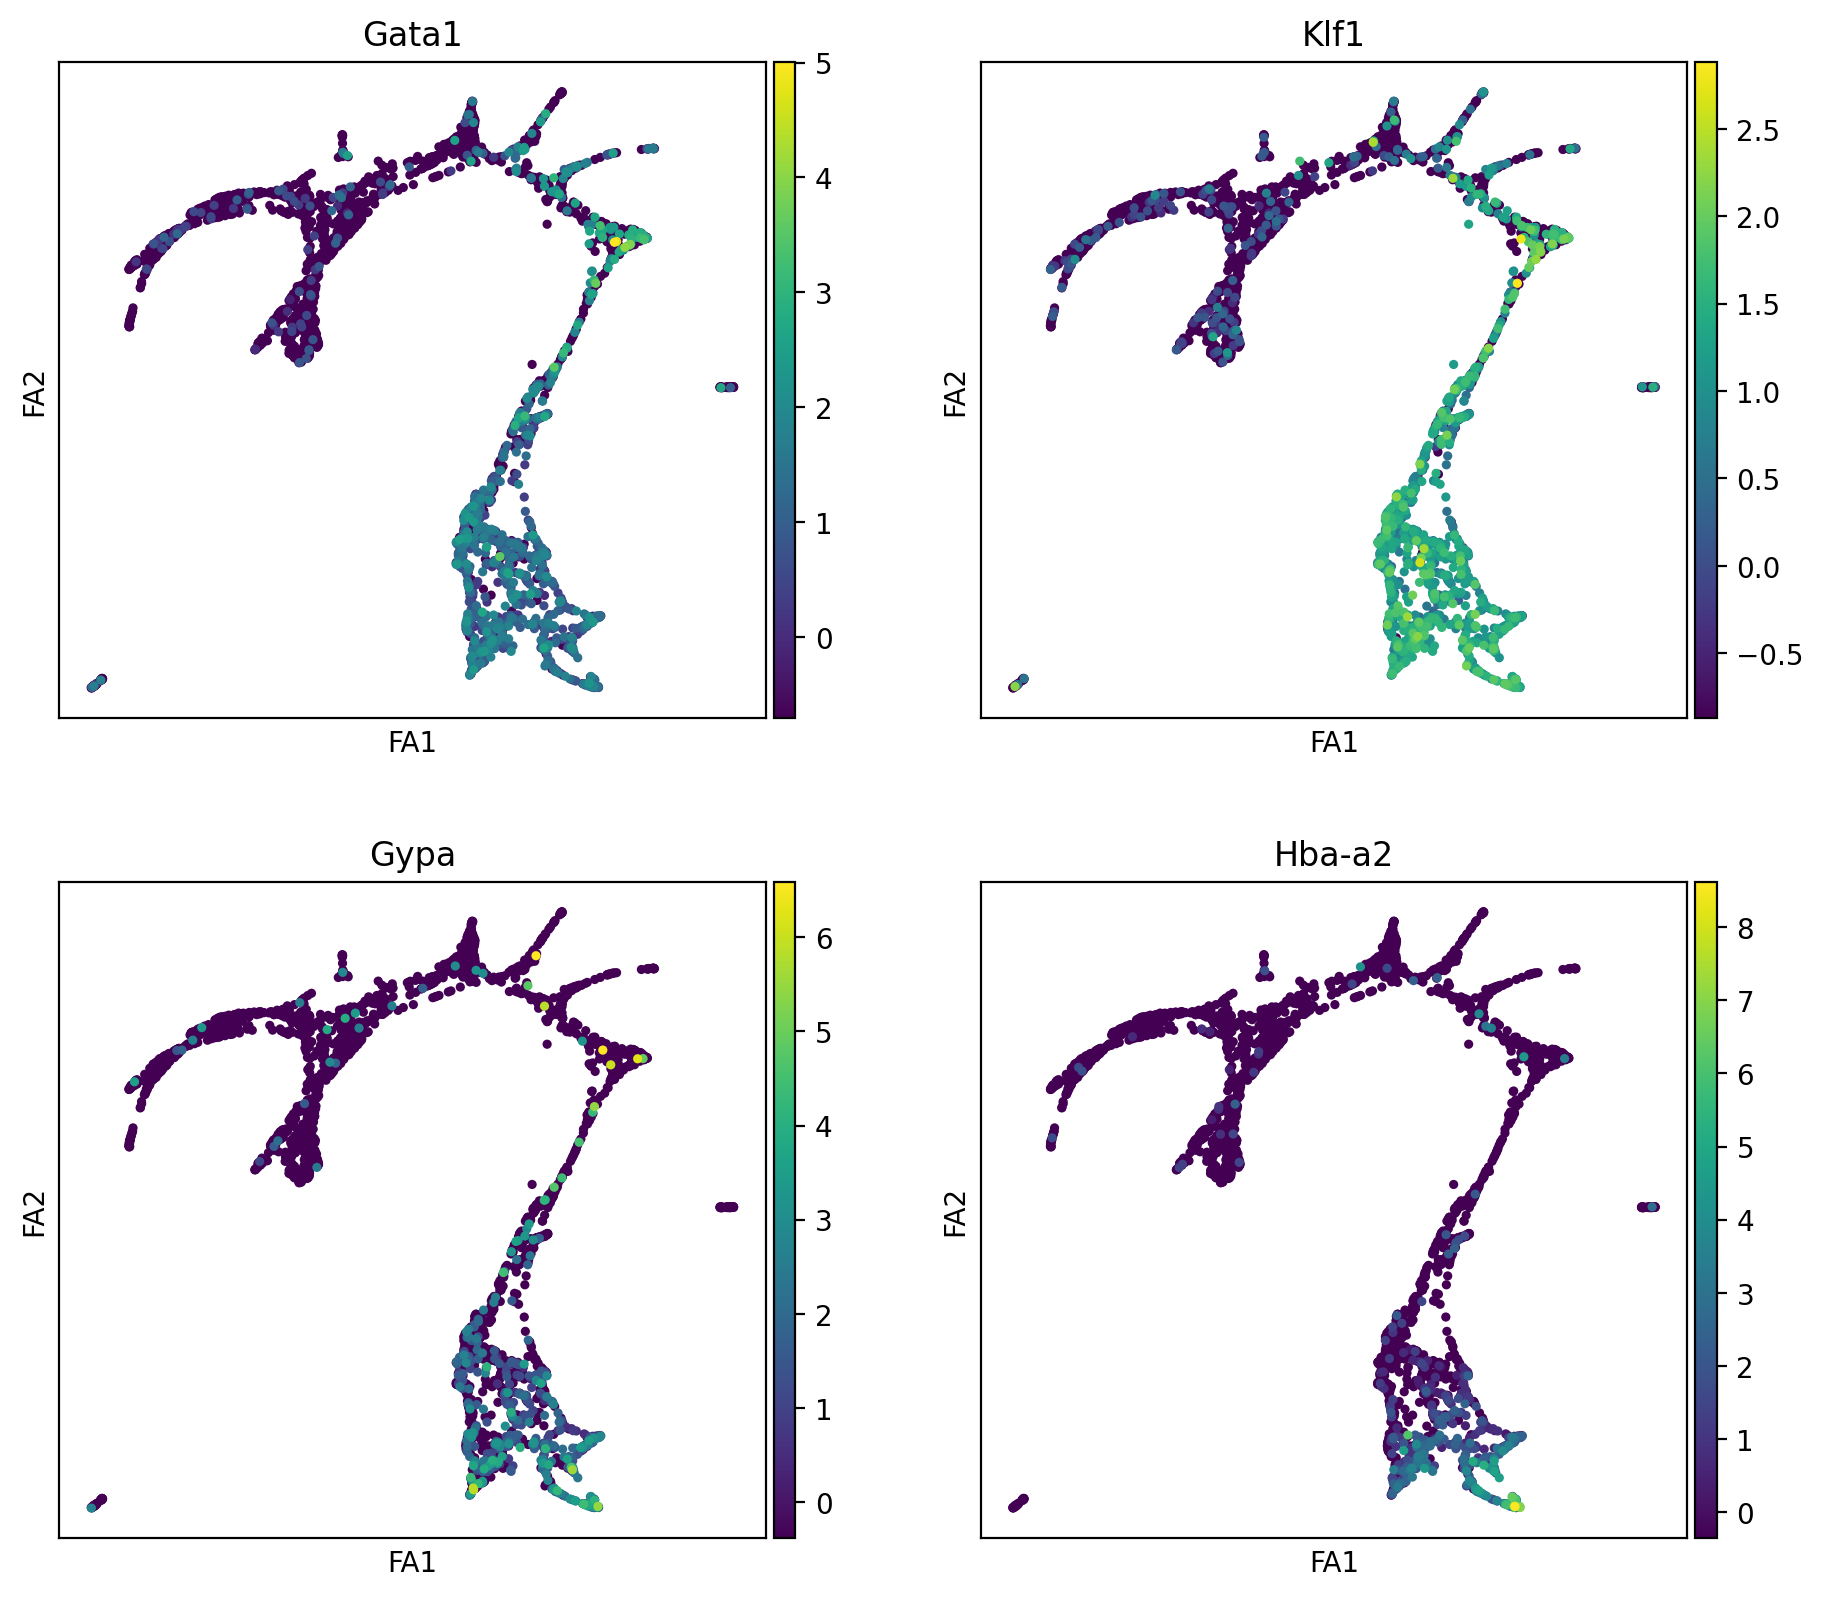

marker gene of Megakaryocytes


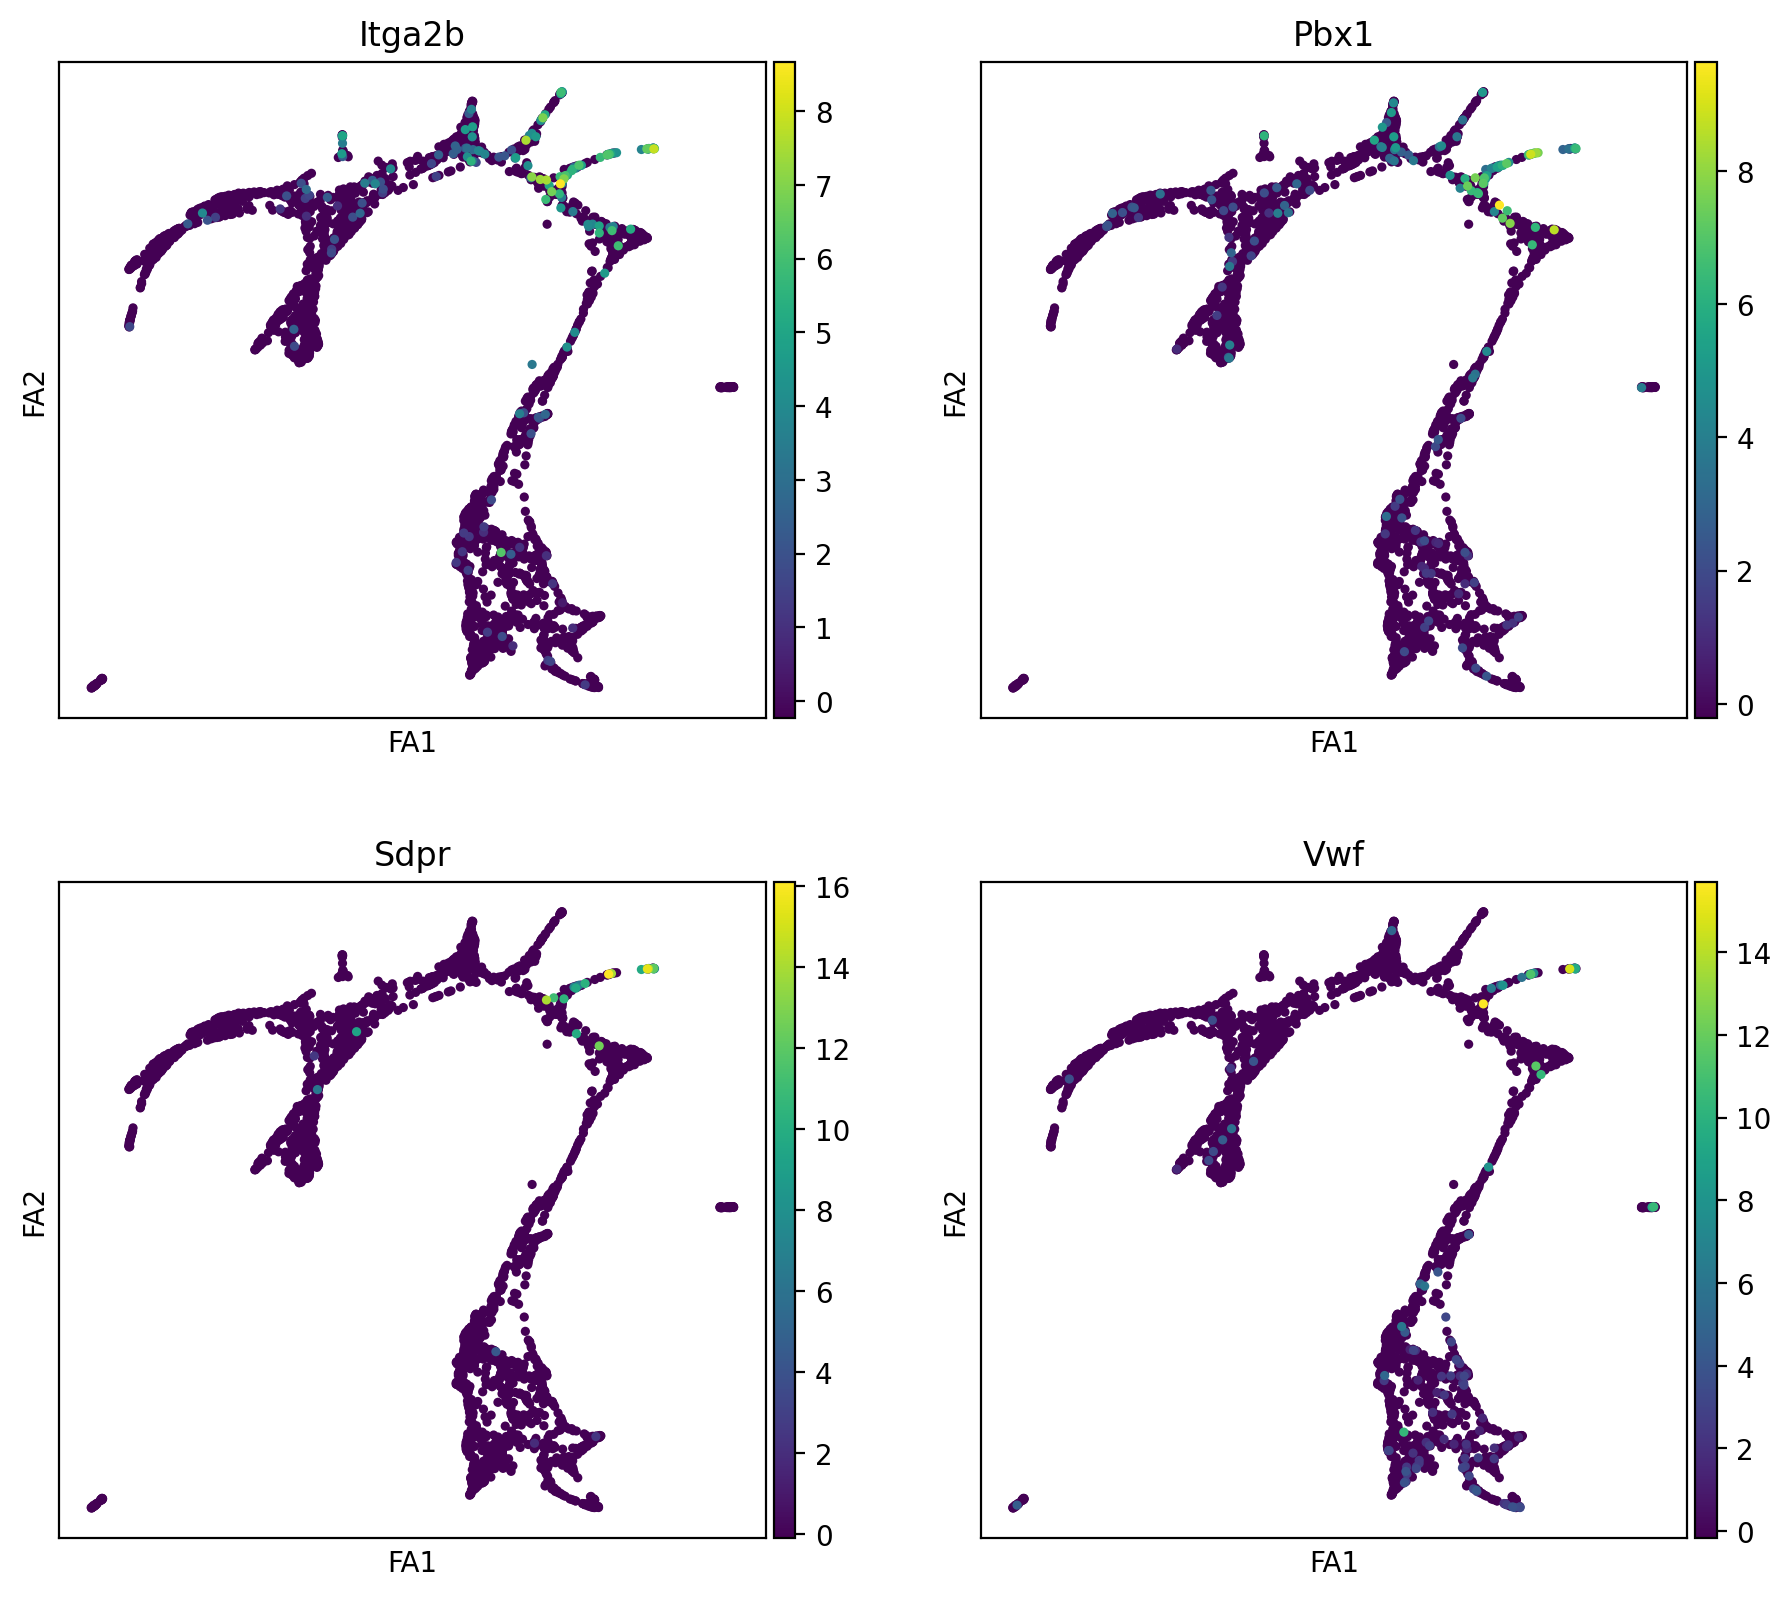

marker gene of Granulocytes


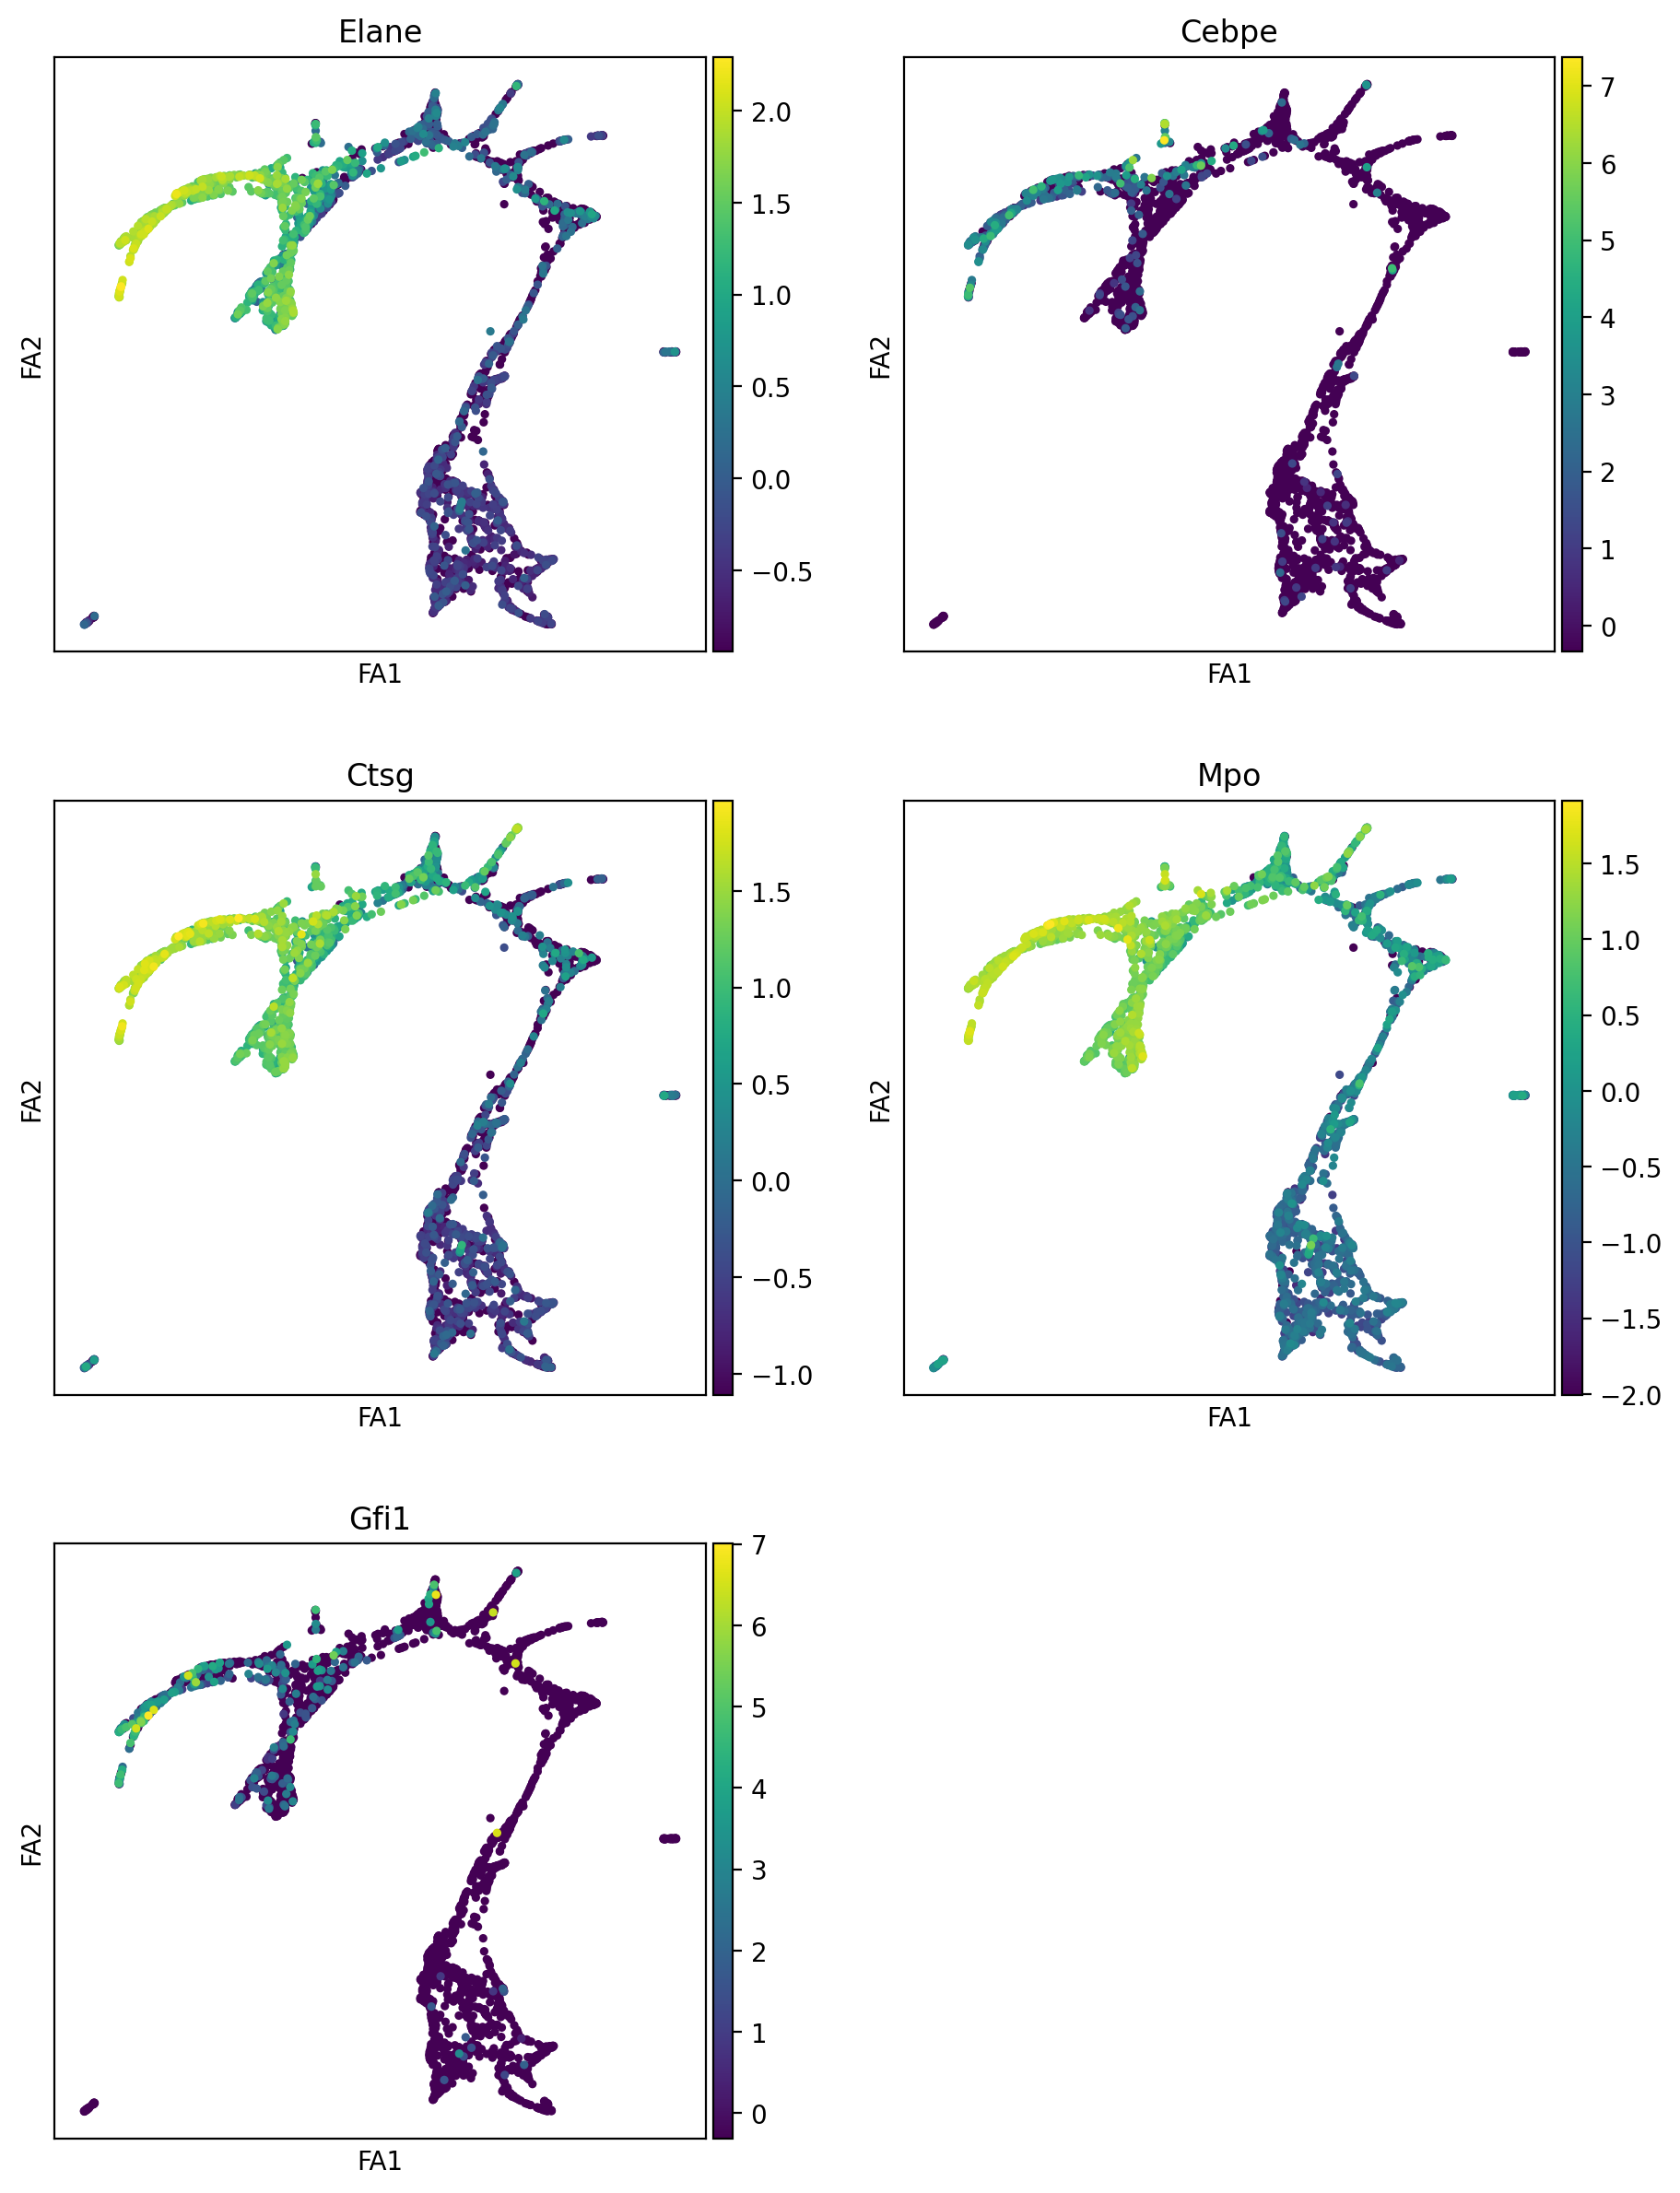

marker gene of Monocytes


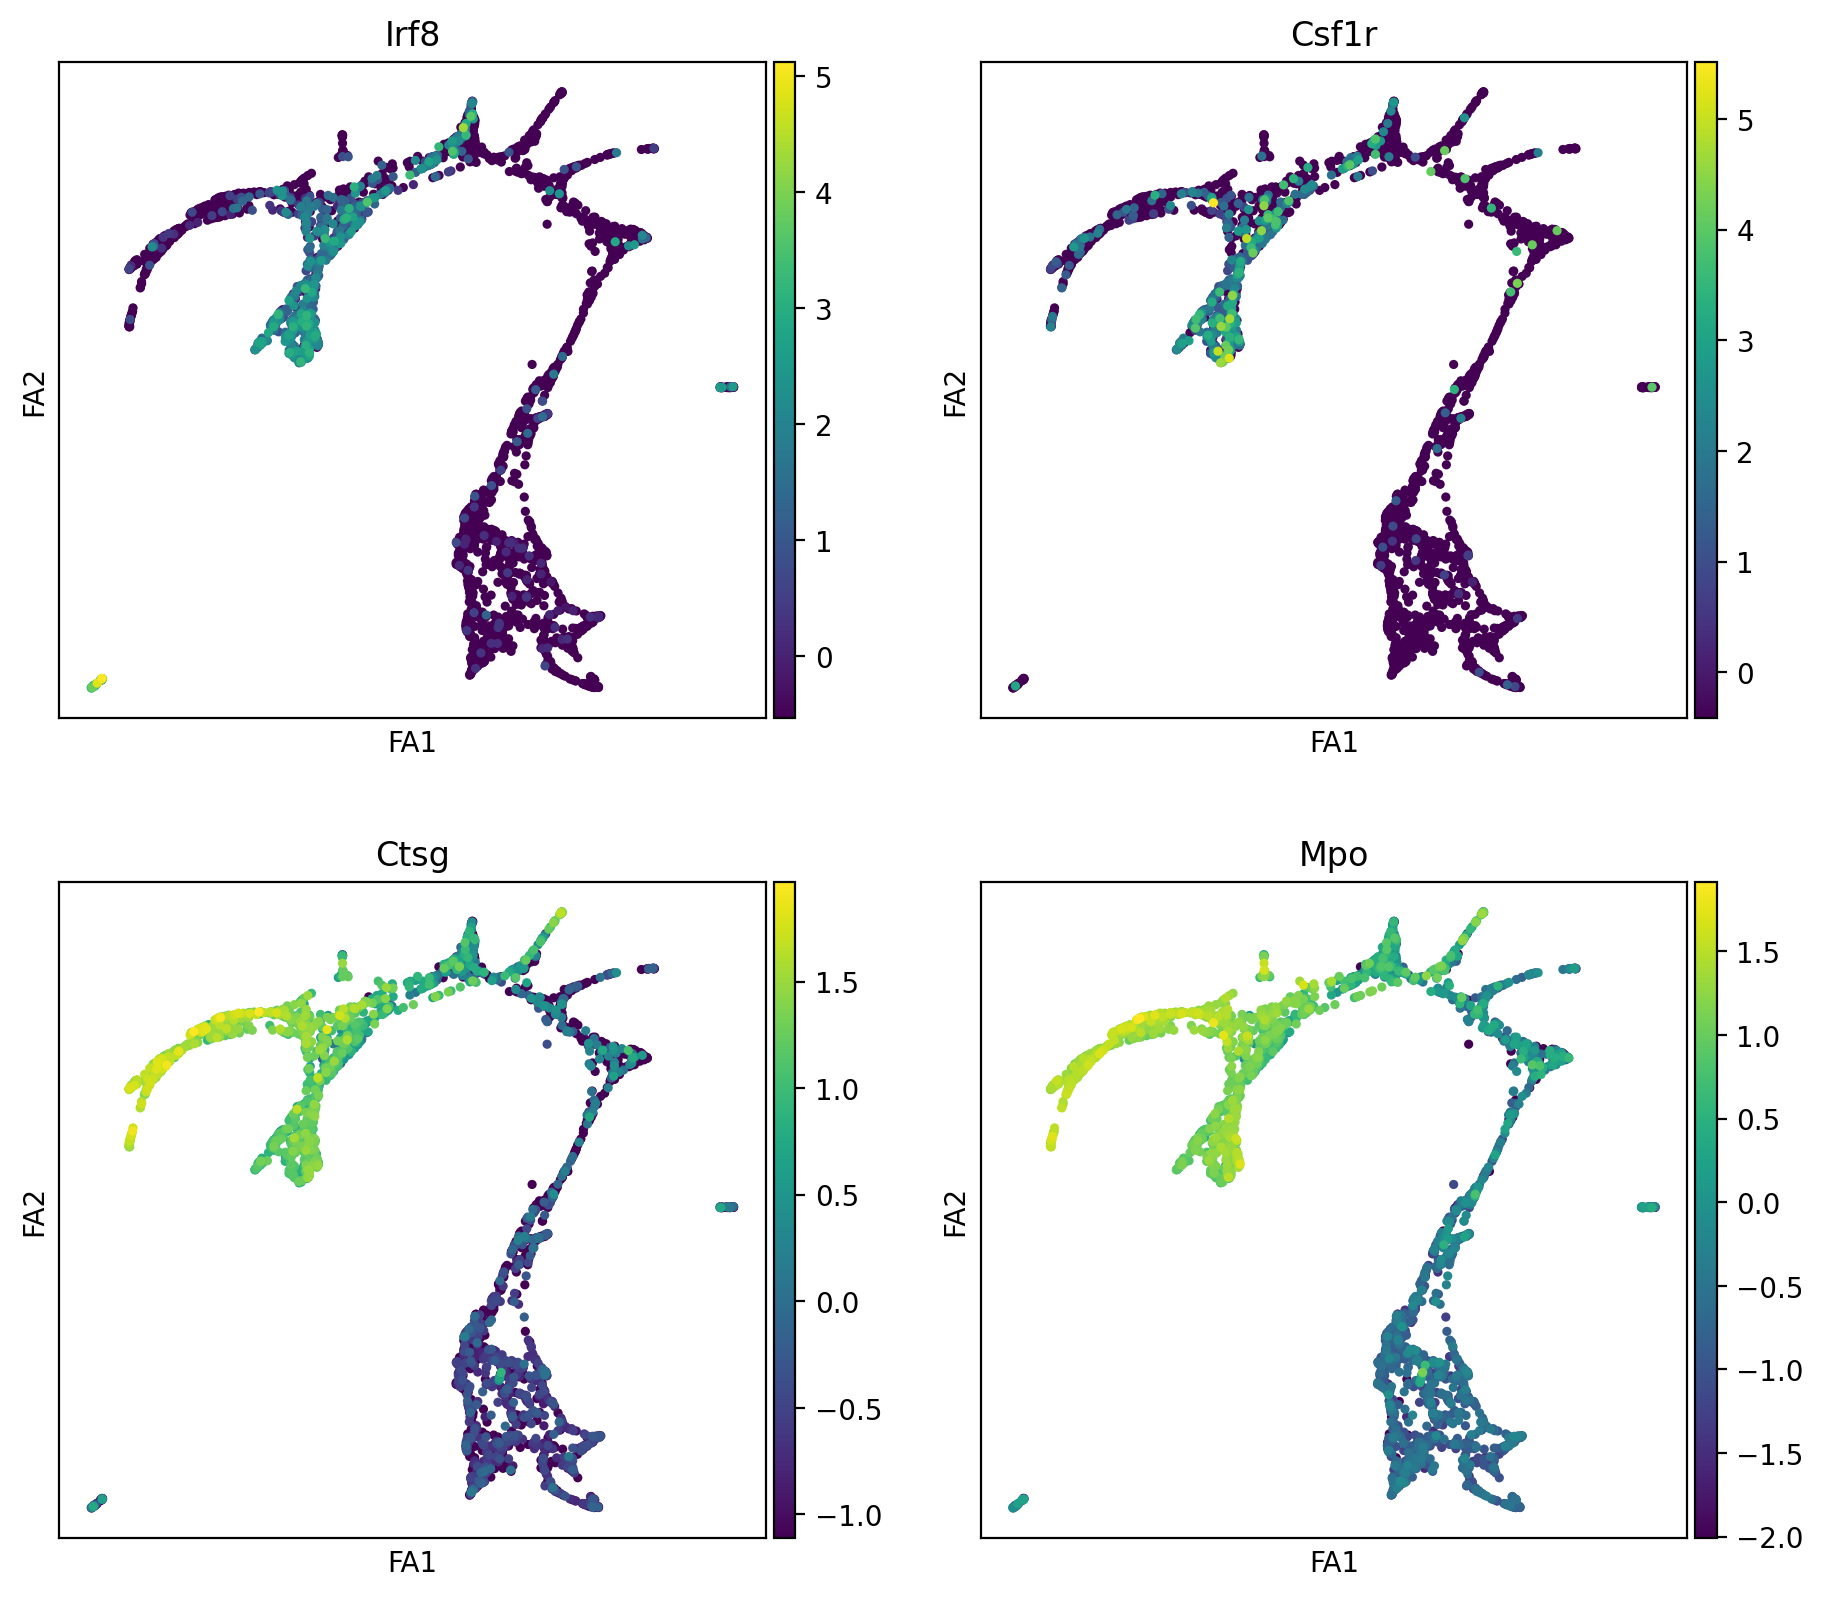

marker gene of Mast_cells


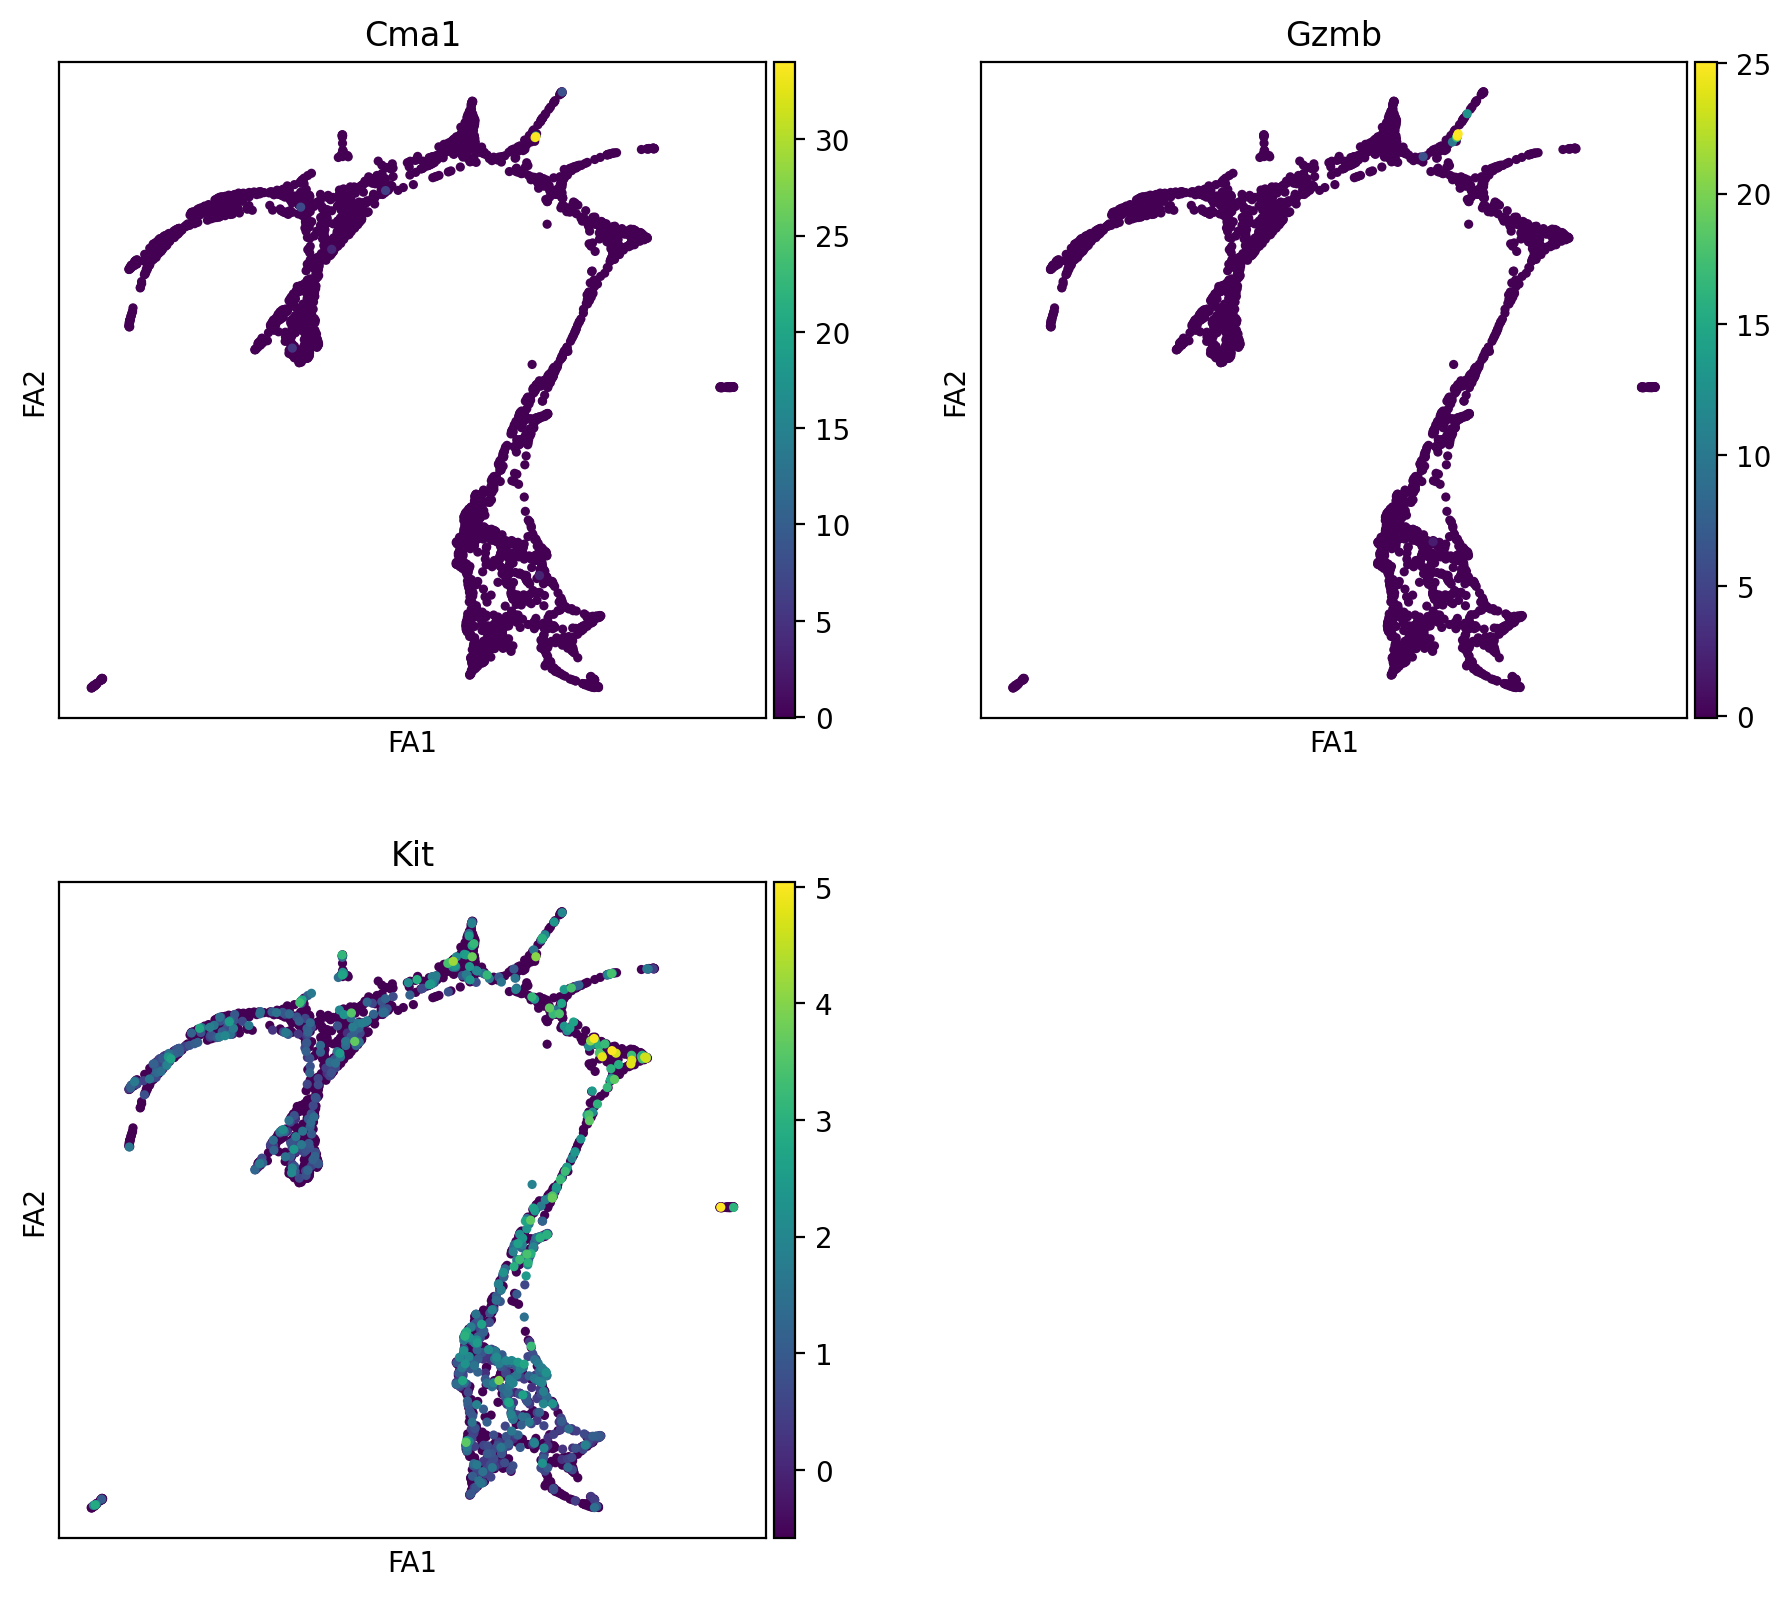

marker gene of Basophils


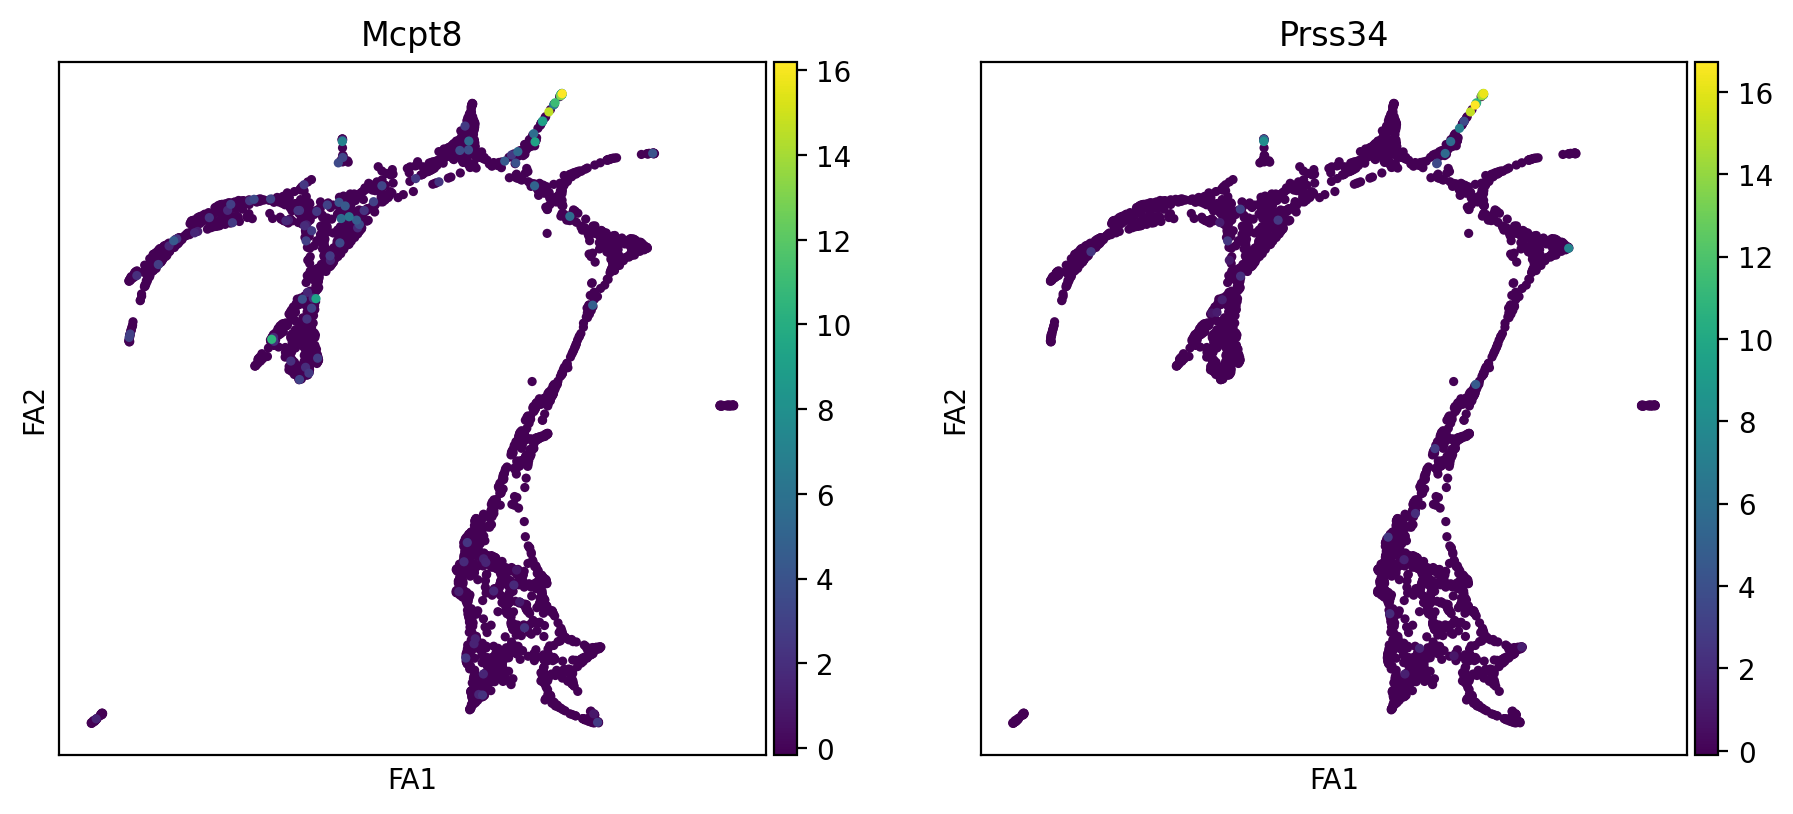

In [20]:
markers = {"Erythroids":["Gata1", "Klf1", "Gypa", "Hba-a2"],
           "Megakaryocytes":["Itga2b", "Pbx1", "Sdpr", "Vwf"],
            "Granulocytes":["Elane", "Cebpe", "Ctsg", "Mpo", "Gfi1"],
            "Monocytes":["Irf8", "Csf1r", "Ctsg", "Mpo"],
            "Mast_cells":["Cma1", "Gzmb", "Kit"],
            "Basophils":["Mcpt8", "Prss34"]
            }

for cell_type, genes in markers.items():
    print(f"marker gene of {cell_type}")
    sc.pl.draw_graph(adata, color=genes, use_raw=False, ncols=2)
    plt.show()



# 10. [Optional step] Cluster annotation

We will annotate the clusters based on the marker gene expression.


## 9.1. Make annotation (1)

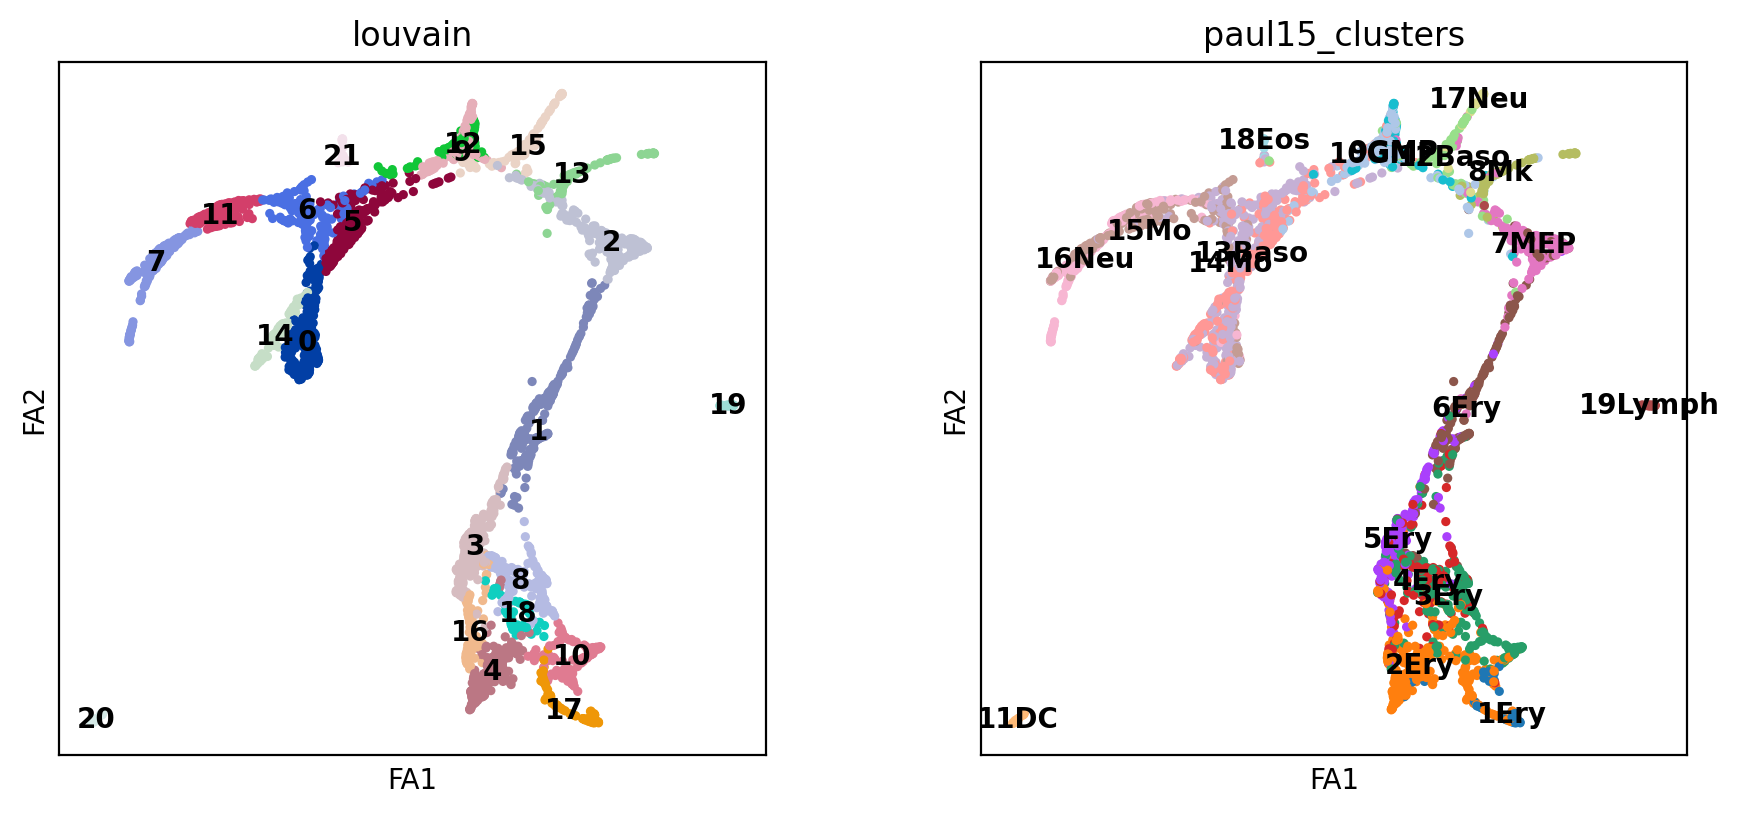

In [ ]:
sc.pl.draw_graph(adata, color=['louvain', 'paul15_clusters'],
                 legend_loc='on data')

# Cluster label	Meaning
# 1Ery	Cluster 1 – Erythroid (red-cell lineage)
# 2Ery	Cluster 2 – Erythroid
# 3Ery	Cluster 3 – Erythroid
# 4Baso	Cluster 4 – Basophils (a granulocyte subtype)
# 5Ery	Cluster 5 – Erythroid
# 6Ery	Cluster 6 – Erythroid
# 7MEP	Cluster 7 – Megakaryocyte–Erythroid Progenitor
# 8Mk	Cluster 8 – Megakaryocytes
# 11DC	Cluster 11 – Dendritic Cells
# 14Baso	Cluster 14 – Basophils
# 15Mono	Cluster 15 – Monocytes
# 16Neu	Cluster 16 – Neutrophils
# 17Neu	Cluster 17 – Neutrophils
# 18Eos	Cluster 18 – Eosinophils
# 19Lymph	Cluster 19 – Lymphocytes

In [24]:
# Check current cluster name
cluster_list = adata.obs.louvain.unique()
cluster_list

['2', '0', '10', '11', '5', ..., '3', '19', '21', '14', '20']
Length: 22
Categories (22, object): ['0', '1', '2', '3', ..., '18', '19', '20', '21']

#### Attention!! Please change the dictionary below depending on the clustering results. The results may change depending on the execution environment.

In [25]:
# Make cluster annotation dictionary
annotation = {"MEP":[5],
              "Erythroids": [15, 10, 16, 9, 8, 14, 19, 3, 12, 18],
              "Megakaryocytes":[17, 22],  
              "GMP":[11, 1],
              "late_GMP" :[0],   
              "Granulocytes":[7, 13, 4],
              "Monocytes":[6, 2],
              "DC":[21],
              "Lymphoid":[20]}

# Change dictionary format
annotation_rev = {}
for i in cluster_list:
    for k in annotation:
        if int(i) in annotation[k]:
            annotation_rev[i] = k
            
# Check dictionary
annotation_rev

{'2': 'Monocytes',
 '0': 'late_GMP',
 '10': 'Erythroids',
 '11': 'GMP',
 '5': 'MEP',
 '1': 'GMP',
 '4': 'Granulocytes',
 '17': 'Megakaryocytes',
 '15': 'Erythroids',
 '6': 'Monocytes',
 '18': 'Erythroids',
 '8': 'Erythroids',
 '13': 'Granulocytes',
 '9': 'Erythroids',
 '12': 'Erythroids',
 '7': 'Granulocytes',
 '16': 'Erythroids',
 '3': 'Erythroids',
 '19': 'Erythroids',
 '21': 'DC',
 '14': 'Erythroids',
 '20': 'Lymphoid'}

In [26]:
adata.obs["cell_type"] = [annotation_rev[i] for i in adata.obs.louvain]

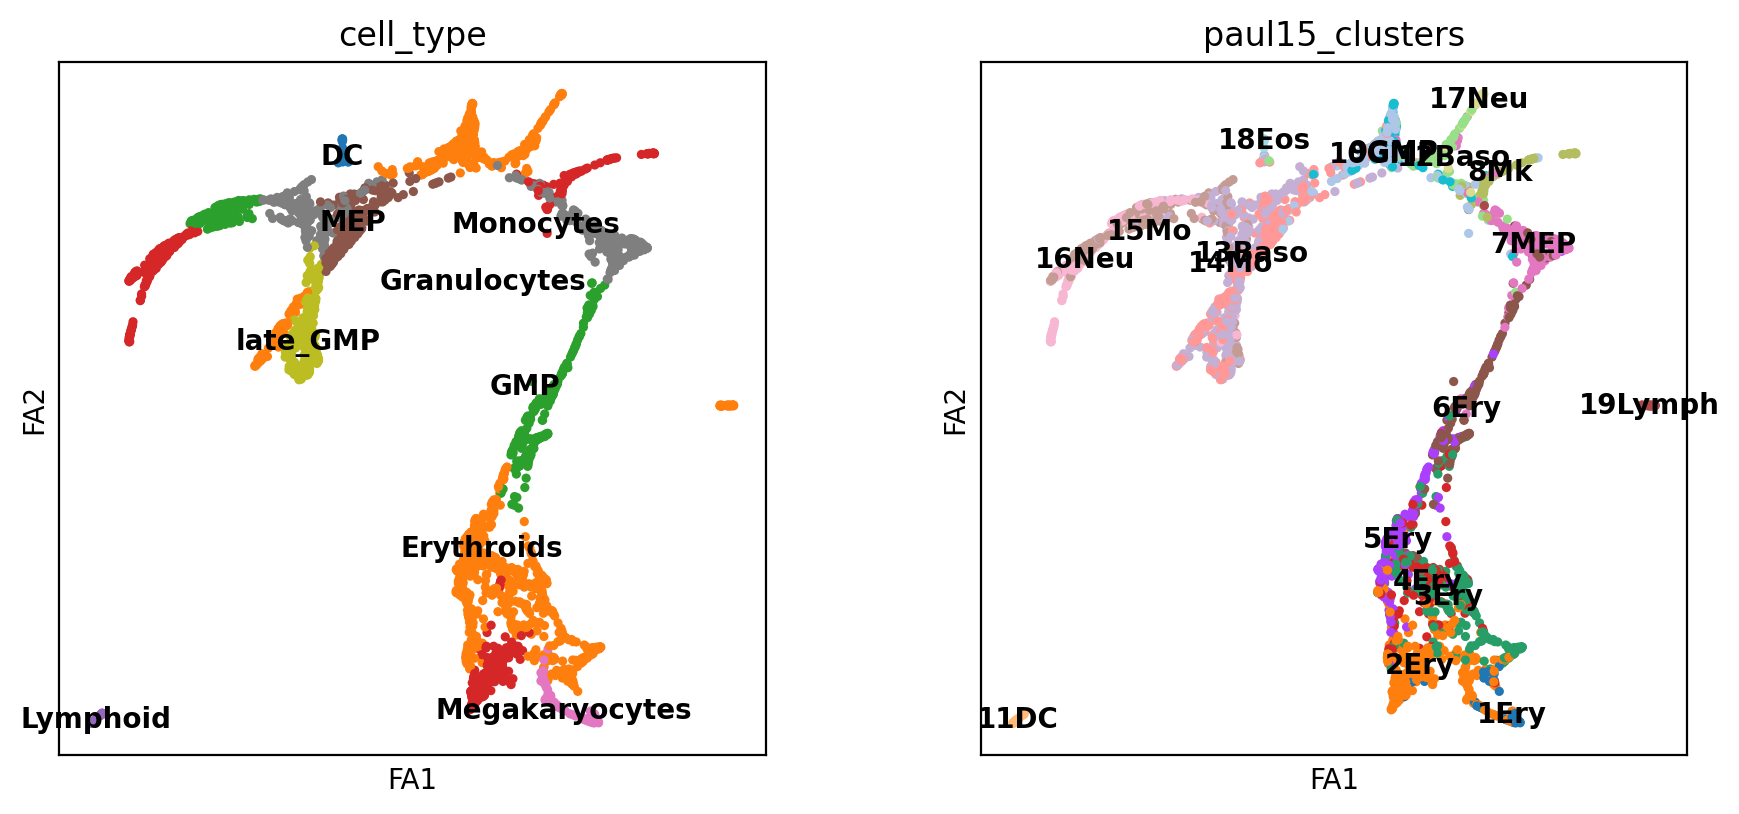

In [27]:
# check results
sc.pl.draw_graph(adata, color=['cell_type', 'paul15_clusters'],
                 legend_loc='on data')

## 10.2. Make annotation (2)
We'll also annotate the indivisual Louvain clusters.

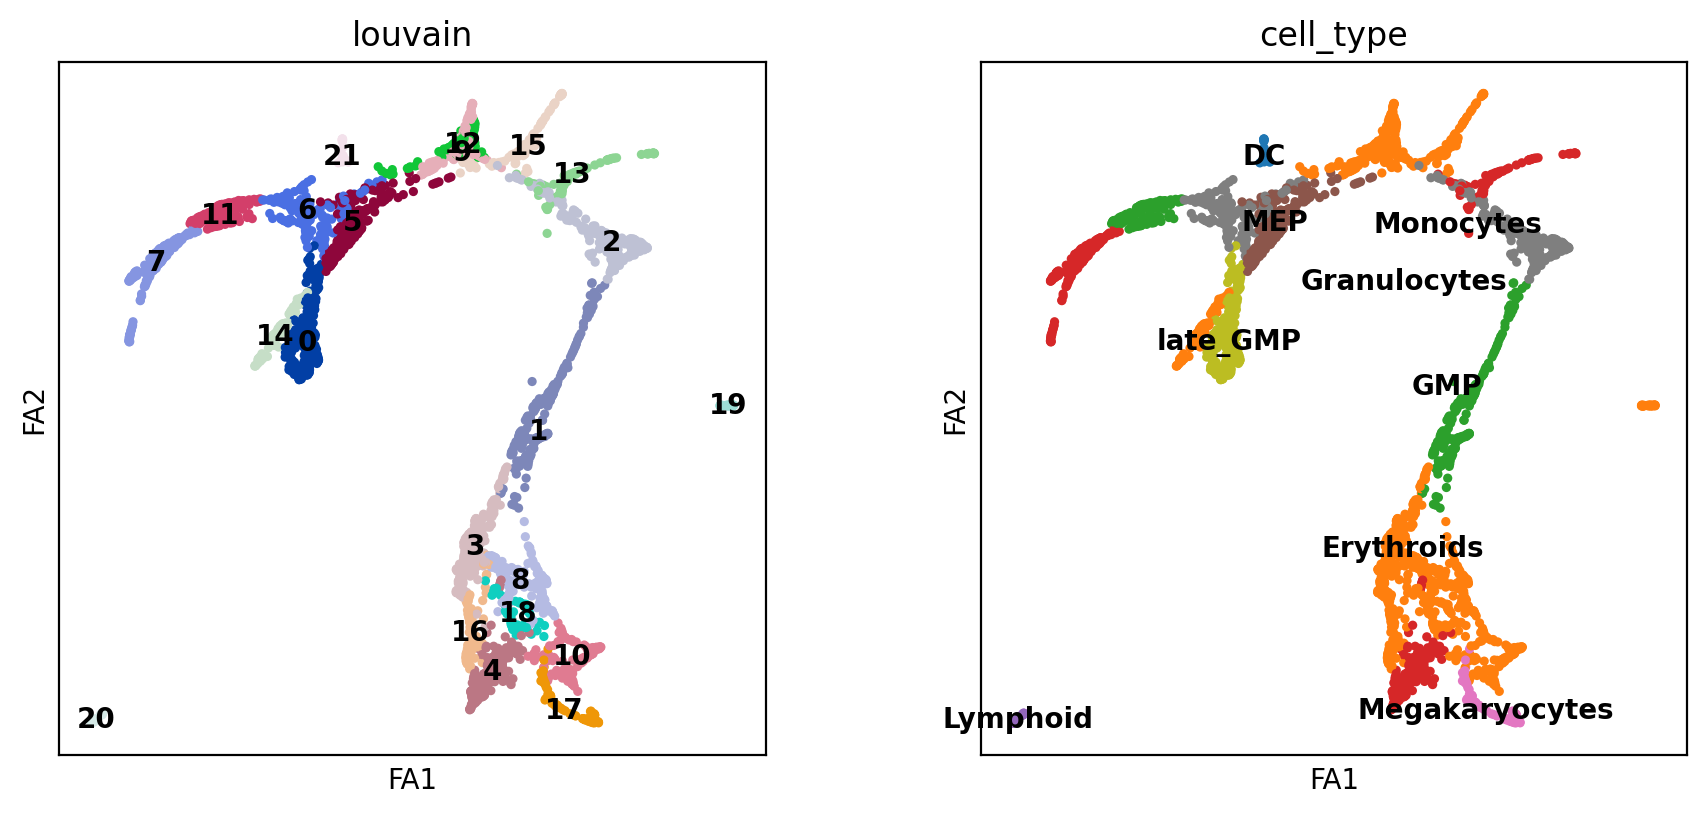

In [29]:
sc.pl.draw_graph(adata, color=['louvain', 'cell_type'],
                 legend_loc='on data')

#### !! Please change the dictionary below depending on the clustering results. The results may change depending on the execution environment.

In [30]:
annotation_2 = {'5': 'MEP_0',
                '15': 'Ery_0',
                '10': 'Ery_1',
                '16': 'Ery_2',
                '14': 'Ery_3',
                '9': 'Ery_4',
                '8': 'Ery_5',
                '19': 'Ery_6',
                '3': 'Ery_7',
                '12': 'Ery_8',
                '18': 'Ery_9',
                '17': 'Mk_0',
                '22': 'Mk_0',
                '11': 'GMP_0',
                '1': 'GMP_1',
                '0': 'GMPl_0',
                '7': 'Gran_0',
                '13': 'Gran_1',
                '4': 'Gran_2',
                '6': 'Mo_0',
                '2': 'Mo_1',
                '21': 'DC_0',
                '20': 'Lym_0'}

In [31]:
adata.obs["louvain_annot"] = [annotation_2[i] for i in adata.obs.louvain]

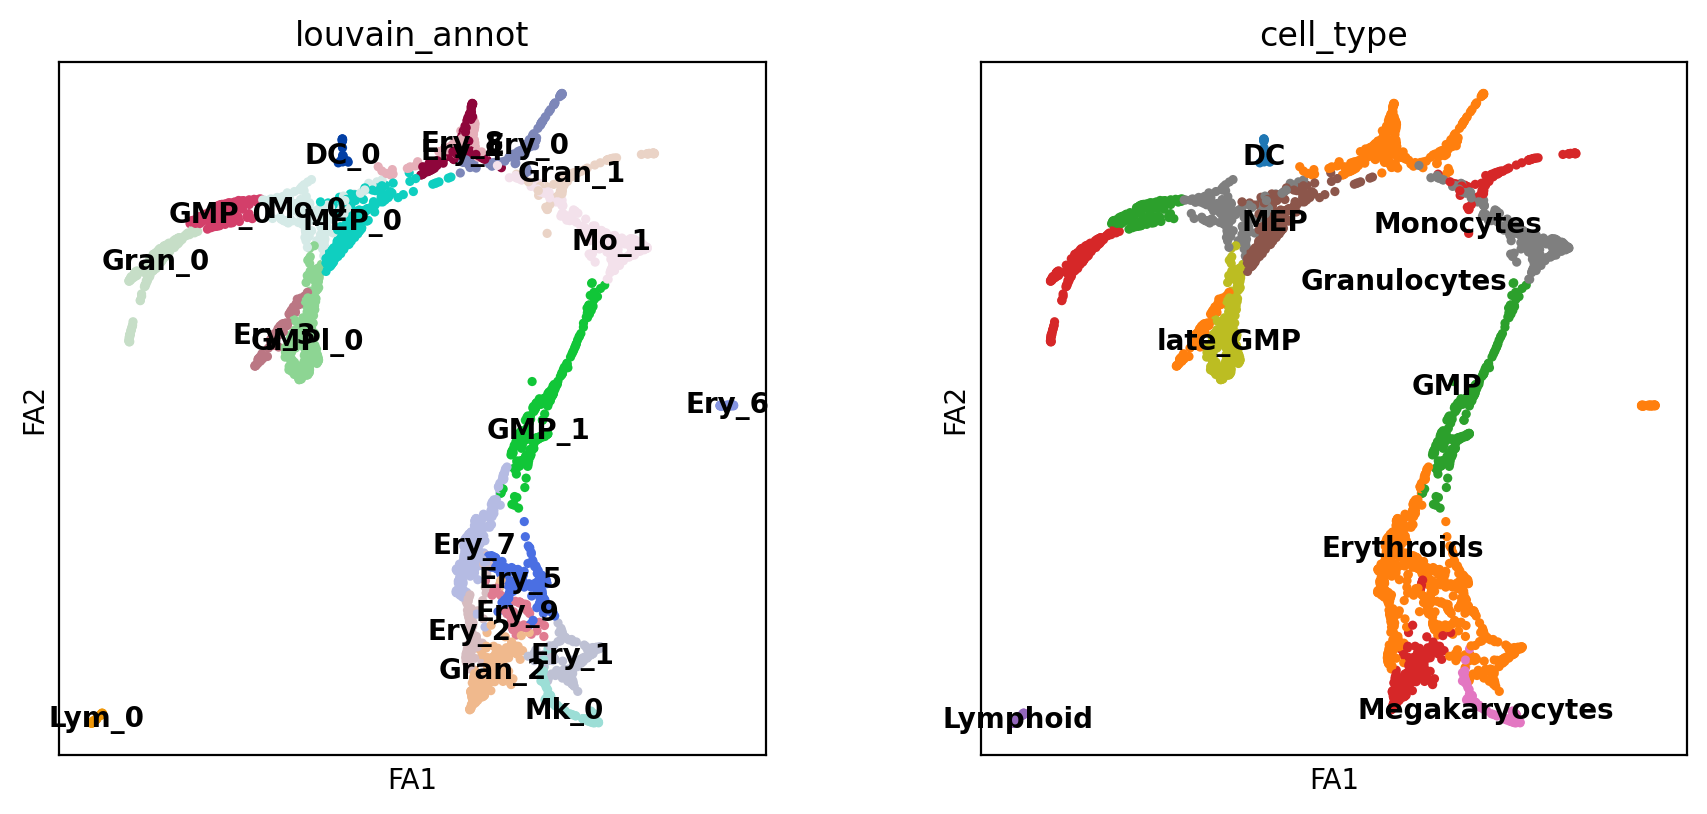

In [32]:
# Check result
sc.pl.draw_graph(adata, color=['louvain_annot', 'cell_type'],
                 legend_loc='on data')

# 11. [Optional step] Subset cells

During the CellOracle analysis, we will focus on the myeloid lineage. Since the othre clusters (i.e. the DC and lymphoid clusters) will not be analyzed, we will choose to remove them now.

It is also important to ensure that the differentiation trajectories are smoothly connected; CellOracle works best with continuous trajectories. If there is discrete cell cluster or non-related cell contamination, please remove them prior to celloracle analysis.

In [33]:
adata.obs.cell_type.unique()

['Monocytes', 'late_GMP', 'Erythroids', 'GMP', 'MEP', 'Granulocytes', 'Megakaryocytes', 'DC', 'Lymphoid']
Categories (9, object): ['DC', 'Erythroids', 'GMP', 'Granulocytes', ..., 'MEP', 'Megakaryocytes', 'Monocytes', 'late_GMP']

In [34]:
cell_of_interest = adata.obs.index[~adata.obs.cell_type.isin(["Lymphoid", "DC"])]
adata = adata[cell_of_interest, :]

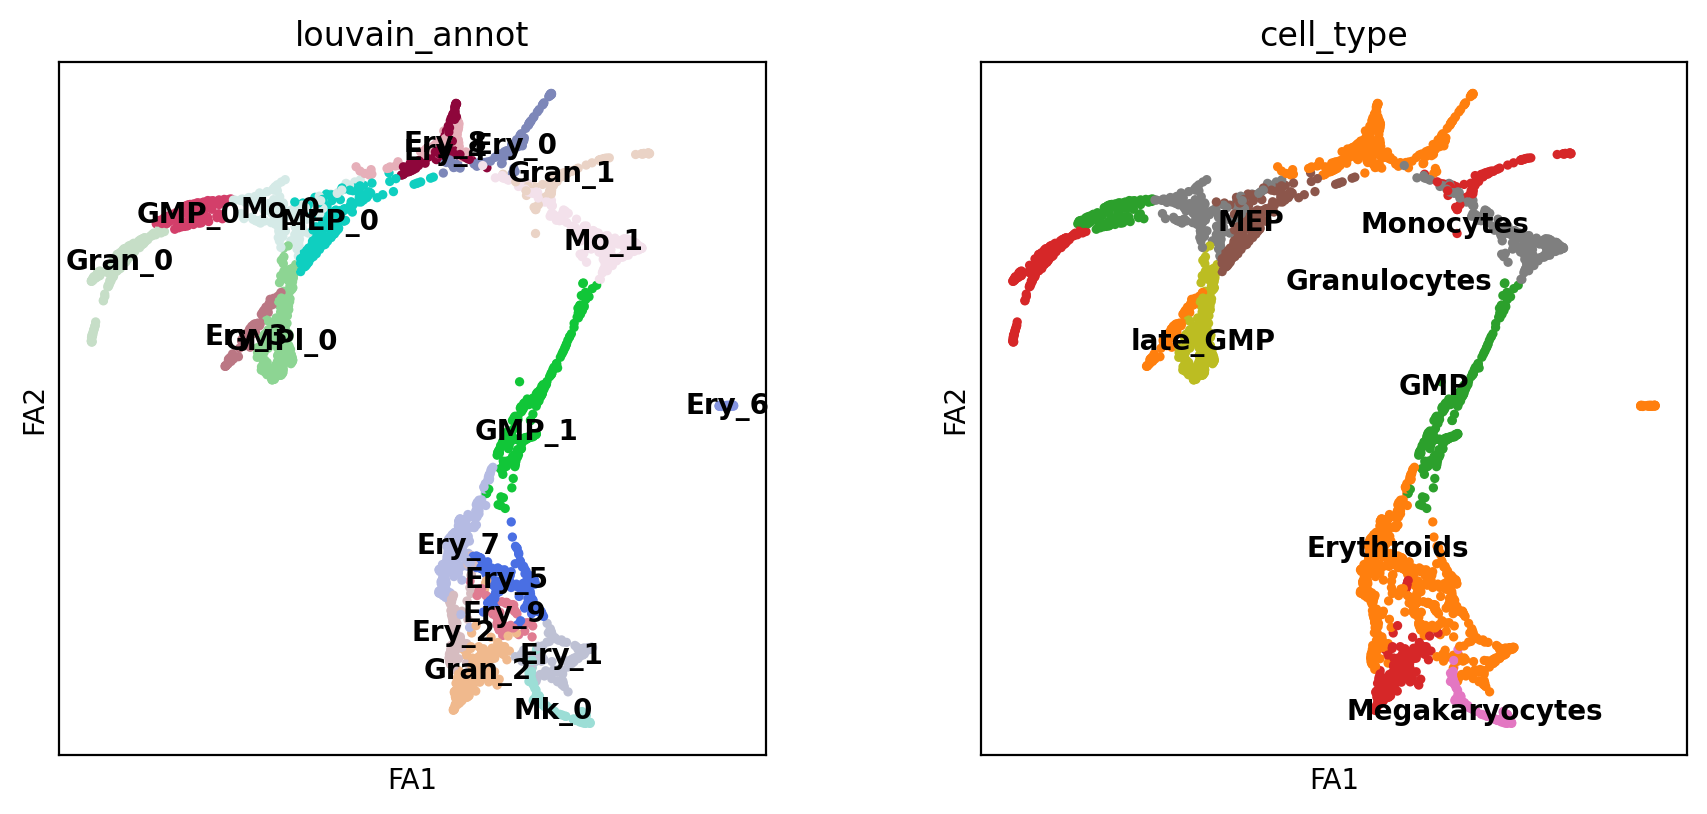

In [35]:
# check result
sc.pl.draw_graph(adata, color=['louvain_annot', 'cell_type'],
                 legend_loc='on data')

# 12. Save processed data

In [36]:
adata.write_h5ad("Paul_etal_15.h5ad")